# import libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sqlite3
import plotly.express as px
import holidays
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.formula.api import glm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras import Sequential
from keras import layers
from keras.models import Model
from keras.layers import LSTM, BatchNormalization, Dropout, Dense, Flatten, Conv1D
from keras.layers import MaxPooling1D, GRU, Input,Masking, Concatenate, dot
from keras.optimizers import Adam, SGD
from keras.losses import MeanAbsoluteError
from keras.metrics import RootMeanSquaredError
from keras.callbacks import EarlyStopping
from keras.callbacks import LearningRateScheduler
import xgboost as xgb
import tensorflow as tf
import tensorflow_addons as tfa
import shap

/Users/khang/anaconda3/envs/my_env/lib/python3.8/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
import nbimporter
%run -i Common_Functions.ipynb
from Common_Functions import *

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, Concatenate, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow_addons as tfa

# load data and split

In [4]:
df_scada_price_qld = pd.read_csv('non_demand_price_scada_hourly.csv', index_col = False)
df_scada_price_qld = df_scada_price_qld.set_index('Date_Hour')

In [5]:
df_scada_price_qld.head()

,Bagasse_Generation,Bagasse_and_Diesel_Generation,Black_Coal_Generation,Coal_Seam_Methane_Generation,Grid_Generation,Kerosene_Generation,Natural_Gas_Generation,Solar_Generation,Solar__Generation,Waste_Coal_Mine_Gas_Generation,Water_Generation,Wind_Generation,RRP,Hour,Month,WeekDay,Year
Date_Hour,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,0.0,0.0,62858.98551,0.0,0.0,0.0,3975.97976,6.171,0.0,746.831214,1681.9350,1085.28027,64.605948,0,1,1,2019
2019-01-01 01:00:00,0.0,0.0,67183.38066,0.0,0.0,0.0,4304.76559,6.732,0.0,669.637499,1834.1200,1416.38041,66.544864,1,1,1,2019
2019-01-01 02:00:00,0.0,0.0,65502.50779,0.0,0.0,0.0,4109.34554,6.732,0.0,896.243756,1829.3100,1539.30137,61.140174,2,1,1,2019
2019-01-01 03:00:00,0.0,0.0,63496.45470,0.0,0.0,0.0,4091.15064,6.732,0.0,930.731348,1829.7750,1581.81376,52.883149,3,1,1,2019
2019-01-01 04:00:00,0.0,0.0,61761.28180,0.0,0.0,0.0,4096.64811,6.732,0.0,902.593736,1832.4225,1613.19730,49.505579,4,1,1,2019


In [6]:
X = df_scada_price_qld.drop(['RRP', 'Solar__Generation'], axis = 1)
y = df_scada_price_qld[['RRP']]

In [45]:
def apply_PCA(X_input, cum_variance, if_apply):
    
    if if_apply:
    
        pca = PCA(n_components = cum_variance)
        # make pipeline to first standardize then apply PCA on data
        scaler_pca = make_pipeline(MinMaxScaler(), pca)
        X_pca = scaler_pca.fit(X_input).transform(X_input)

        return X_pca
    
    else:
        
        return np.array(X_input)

In [46]:
params_pca = {'cum_variance' : 0.8, 'if_apply' : True }
X_pca = apply_PCA(X, **params_pca)
X_pca.shape

(52608, 6)

In [47]:
def windowing(X_input,y_input, history_size):
    
    data = []
    labels = []
    for i in range(history_size, len(y_input)):
        data.append(X_input[i - history_size : i, :])
        labels.append(y_input[i])
        
    return np.array(data), np.array(labels).reshape(-1,1)

In [48]:
train_cutoff = int(0.8*X_pca.shape[0])
val_cutoff   = int(0.9*X_pca.shape[0])

scaler_y = MinMaxScaler()
scaler_y.fit(y[:train_cutoff])
y_norm = scaler_y.transform(y)

In [49]:
hist_size= 24
data_norm = np.concatenate((X_pca,y_norm), axis = 1)

X_train, y_train = windowing(data_norm[:train_cutoff,:],data_norm[:train_cutoff,-1], hist_size)
X_val, y_val     = windowing(data_norm[train_cutoff :val_cutoff,:],data_norm[train_cutoff:val_cutoff,-1], hist_size)
X_test, y_test   = windowing(data_norm[val_cutoff :,:],data_norm[val_cutoff:,-1], hist_size)

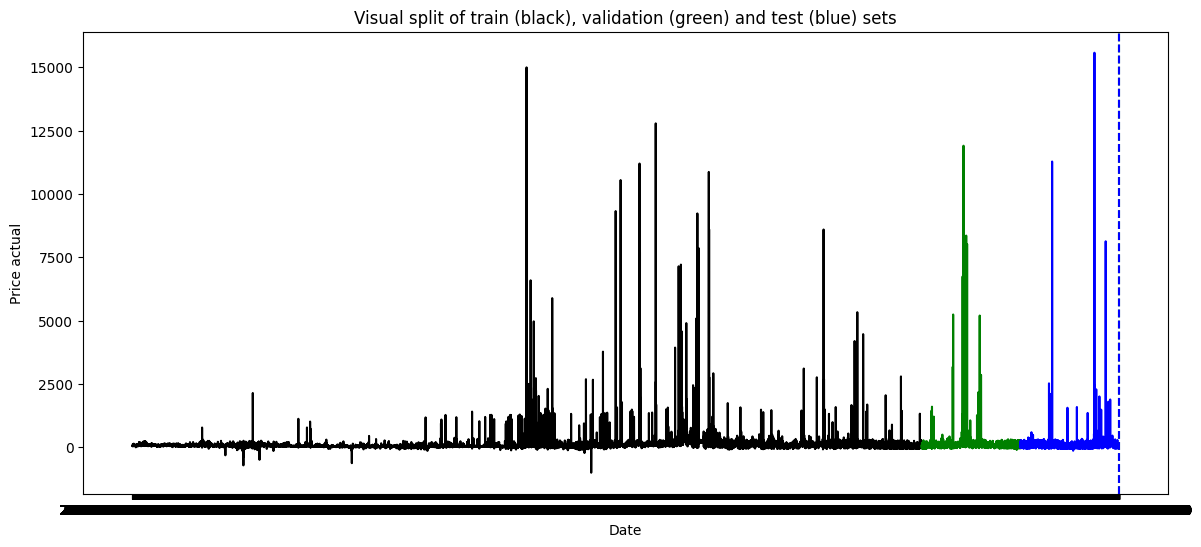

In [12]:
fig, axes = plt.subplots(figsize = (14,6))
axes.plot(df_scada_price_qld['RRP'].iloc[:train_cutoff], color = 'black')
axes.plot(df_scada_price_qld['RRP'].iloc[train_cutoff + 1 : val_cutoff], color = 'green')
axes.plot(df_scada_price_qld['RRP'].iloc[val_cutoff + 1 :], color = 'blue')
axes.axvline(x=df_scada_price_qld.index[train_cutoff], color='green', linestyle='--')
axes.axvline(x=df_scada_price_qld.index[val_cutoff], color='blue', linestyle='--')
axes.set_title('Visual split of train (black), validation (green) and test (blue) sets')
axes.set_xlabel('Date')
axes.set_ylabel('Price actual')
plt.show()

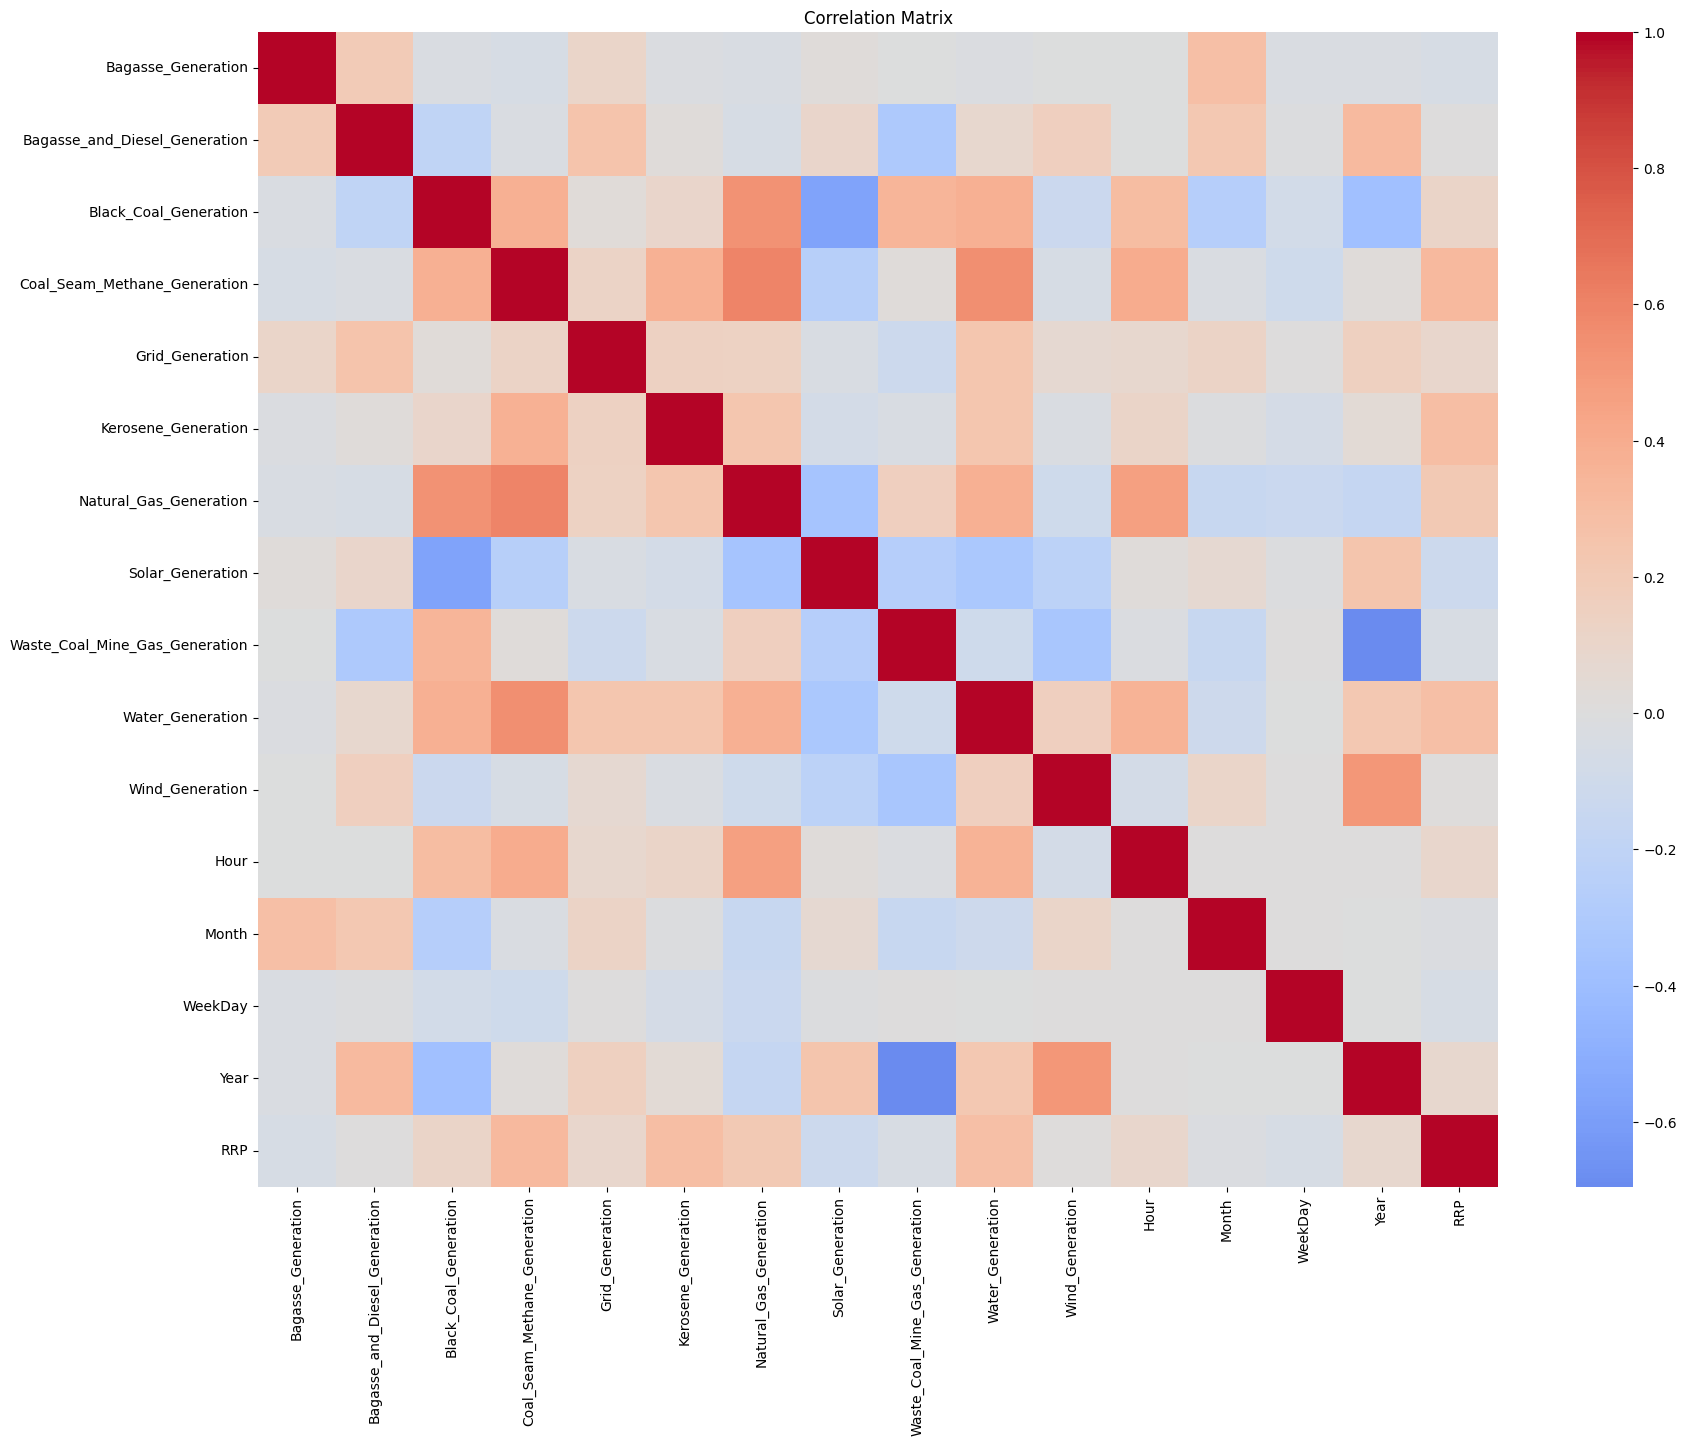

In [50]:
# Plot correlation matrix
plt.figure(figsize=(20, 15))
corr_matrix = pd.concat([X, y], axis=1).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# models build

## Attention-LSTM + XGBoost

In [20]:
# inputs for DL models
epoch = 100
batch_size = 64
steps_per_epoch = len(X_train) // batch_size
cyclic_lr = tfa.optimizers.CyclicalLearningRate(initial_learning_rate=1e-04,
                                                maximal_learning_rate=1e-02,
                                                scale_fn=lambda x: 1/(2**(x-1)),
                                                step_size=6 * steps_per_epoch)

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8)
optimizer = Adam(learning_rate=cyclic_lr, amsgrad=True)

In [26]:
def LSTM_attention():
    inputs = Input(shape=(hist_size, X_train.shape[2]))
    #By masking the zeros, the model can learn to ignore the missing values and focus on the valid data.
    masked = Masking(mask_value=0.)(inputs)
    lstm = LSTM(132, return_sequences=True)(masked)
    attention = dot([lstm, lstm], axes=[2, 2])
    # extracting weight for every observation in the history size!
    attention = Dense(hist_size, activation='softmax')(attention)
    # assinging weight to lstm by dot product
    context = dot([attention, lstm], axes=[2, 1])
    flattened = Flatten()(context)
    output = Dense(1)(flattened)
    model = Model(inputs=inputs, outputs=output)
    
    return model
    
LSTM_attention_model = LSTM_attention()
LSTM_attention_model.compile(optimizer=optimizer, loss='mae')

In [13]:
def reshaping(X):
    
    reshaped_x = X.reshape(-1 , X.shape[1] * X.shape[2])
    return reshaped_x

X_train_xgb = reshaping(X_train)
X_val_xgb   = reshaping(X_val)
X_test_xgb  = reshaping(X_test)

In [28]:
print('LSTM-Attention is fitting a model on train-validation sets...')
print('')

LSTM_attention_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = epoch, 
                   batch_size = batch_size, callbacks=[callback])

print('')
print('----------------------------------')
print('LSTM-attention is predicting...')
print('')

residuals_train = y_train - LSTM_attention_model.predict(X_train)
residuals_val   = y_val - LSTM_attention_model.predict(X_val)

print('')
print('----------------------------------')
print('XGBoost is fitting a model on residuals...')
print('')

LSTM-Attention is fitting a model on train-validation sets...

Epoch 1/100
658/658 [==============================] - 13s 17ms/step - loss: 0.0071 - val_loss: 0.0041
Epoch 2/100
658/658 [==============================] - 11s 17ms/step - loss: 0.0047 - val_loss: 0.0038
Epoch 3/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0038 - val_loss: 0.0043
Epoch 4/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0035 - val_loss: 0.0052
Epoch 5/100
658/658 [==============================] - 11s 17ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 6/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0032 - val_loss: 0.0059
Epoch 7/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0030 - val_loss: 0.0047
Epoch 8/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0028 - val_loss: 0.0043
Epoch 9/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 10/1

TypeError: fit() got an unexpected keyword argument 'eval_metric'

In [33]:
xgb_hybrid = xgb.XGBRegressor(     
               eval_metric='mae',
               early_stopping_rounds=8,
               verbose=False)
xgb_hybrid.fit(X_train_xgb, residuals_train,eval_set=[(X_train_xgb, residuals_train), (X_val_xgb, residuals_val)]) 


y_train_pred = LSTM_attention_model.predict(X_train) + xgb_hybrid.predict(X_train_xgb).reshape(-1,1)
y_val_pred   = LSTM_attention_model.predict(X_val)   + xgb_hybrid.predict(X_val_xgb).reshape(-1,1)

[0]	validation_0-mae:0.00210	validation_1-mae:0.00291
[1]	validation_0-mae:0.00200	validation_1-mae:0.00294
[2]	validation_0-mae:0.00193	validation_1-mae:0.00305
[3]	validation_0-mae:0.00187	validation_1-mae:0.00316
[4]	validation_0-mae:0.00181	validation_1-mae:0.00320
[5]	validation_0-mae:0.00178	validation_1-mae:0.00325
[6]	validation_0-mae:0.00174	validation_1-mae:0.00343
[7]	validation_0-mae:0.00170	validation_1-mae:0.00345
[8]	validation_0-mae:0.00166	validation_1-mae:0.00345
  17/1315 [..............................] - ETA: 4s 

[14:00:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "verbose" } are not used.



164/164 [==============================] - 0s 3ms/step


In [65]:
def plot_results(y_pred_actual, y_test_inv, model, model_name):
    fig, ax = plt.subplots(2, 1, figsize=(12, 6))
    
    ax[0].plot(y_pred_actual[:1000])
    ax[0].plot(y_test_inv[:1000])
    ax[0].legend(['prediction', 'actual'], loc='upper left')
    ax[0].set_title(f'Prediction vs actual price for test set ({model_name})')
    ax[0].set_xlabel('Observation')
    ax[0].set_ylabel('Price')
     
    if model != 'hybrid':
    
        if model_name == 'XGBoost':

            train_mae = model.evals_result()['validation_0']['mae']
            val_mae = model.evals_result()['validation_1']['mae']
            ax[1].plot(train_mae, label='Training MAE')
            ax[1].plot(val_mae, label='Validation MAE')

        else:

            ax[1].plot(history.history['loss'], label='Training Loss')
            ax[1].plot(history.history['val_loss'], label='Validation Loss')

        ax[1].legend()
        ax[1].set_title(f'Training and validation MAE ({model_name})')
        ax[1].set_xlabel('Iteration/Epochs')
        ax[1].set_ylabel('MAE')    
        
    fig.tight_layout()
    plt.show()

164/164 [==============================] - 1s 3ms/step


---------------------------------------------------
LSTM-Attention-XGBoost MAE for test set : 0.00416
---------------------------------------------------



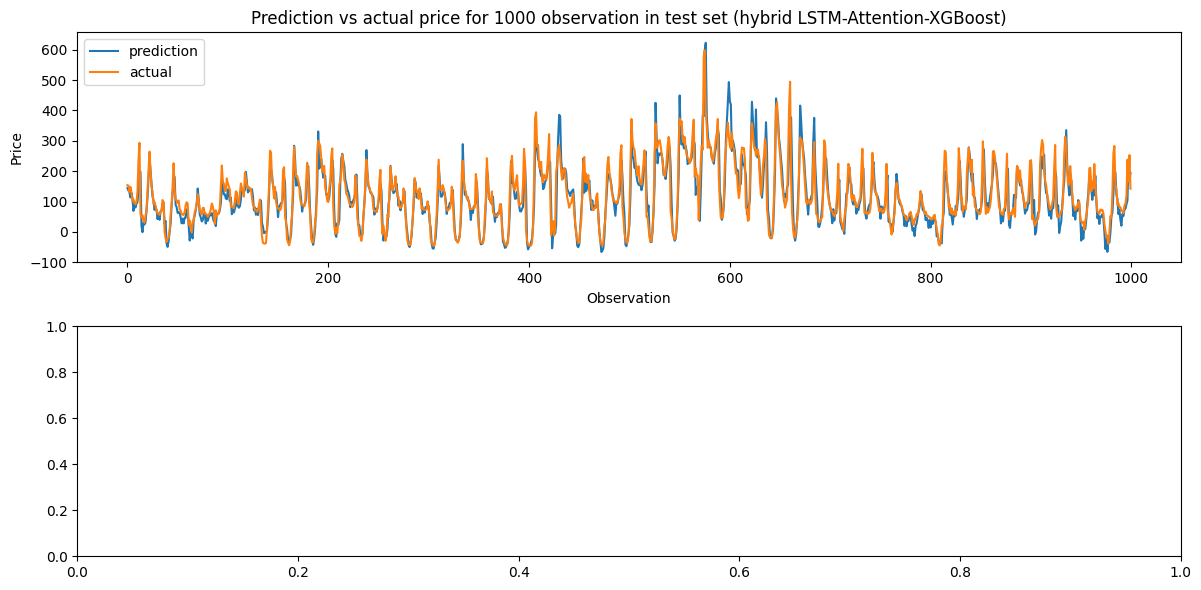

In [37]:
y_test_inv = scaler_y.inverse_transform(y_test)
y_test_pred  = LSTM_attention_model.predict(X_test) + xgb_hybrid.predict(X_test_xgb).reshape(-1,1)
print('')
print('')

print('---------------------------------------------------')
print(f'LSTM-Attention-XGBoost MAE for test set : {round(mean_absolute_error(y_test_pred,y_test),5)}')
print('---------------------------------------------------')
y_pred_actual = scaler_y.inverse_transform(y_test_pred)
print('')
plot_results(y_pred_actual, y_test_inv, 'hybrid' ,'hybrid LSTM-Attention-XGBoost')

## CNN + LSTM 

In [38]:
def base_model_cnn_lstm():
    
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=X_train.shape[-2:]))
    model.add(LSTM(units = 8, return_sequences = True, activation="relu"))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(1))
    
    return model

cnn_lstm_model = base_model_cnn_lstm()
cnn_lstm_model.compile(optimizer = optimizer , loss = 'mean_absolute_error')
cnn_lstm_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 22, 64)            1408      
                                                                 
 lstm_3 (LSTM)               (None, 22, 8)             2336      
                                                                 
 flatten_3 (Flatten)         (None, 176)               0         
                                                                 
 dense_6 (Dense)             (None, 256)               45312     
                                                                 
 dense_7 (Dense)             (None, 1)                 257       
                                                                 
Total params: 49313 (192.63 KB)
Trainable params: 49313 (192.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:                                                 scale_fn=lambda x: 1/(2**(x-1)),



In [39]:
history = cnn_lstm_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = epoch, 
                   batch_size = batch_size, callbacks=[callback])

Epoch 1/100
658/658 [==============================] - 3s 3ms/step - loss: 0.0060 - val_loss: 0.0040
Epoch 2/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 3/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0030 - val_loss: 0.0034
Epoch 4/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 5/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0027 - val_loss: 0.0031
Epoch 6/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0028 - val_loss: 0.0040
Epoch 7/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 8/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0025 - val_loss: 0.0031
Epoch 9/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0024 - val_loss: 0.0035
Epoch 10/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0023 - val_lo

164/164 [==============================] - 0s 633us/step


---------------------------------------------------
CNN-LSTM MAE for test set : 0.00427
---------------------------------------------------



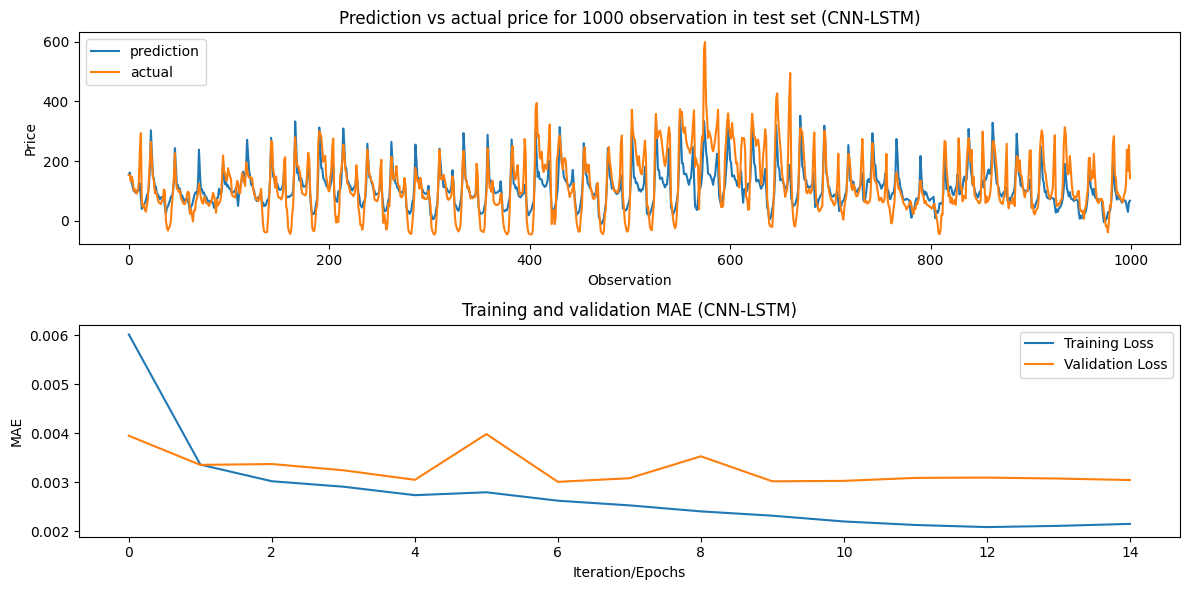

In [40]:
y_pred = cnn_lstm_model.predict(X_test)
print('')
print('')
print('---------------------------------------------------')
print(f'CNN-LSTM MAE for test set : {round(mean_absolute_error(y_pred,y_test),5)}')
print('---------------------------------------------------')
y_pred_actual = scaler_y.inverse_transform(y_pred)
print('')
plot_results(y_pred_actual, y_test_inv, history,'CNN-LSTM')

# training and evaluate for final report

In [53]:
def evaluate_model(model, X_test, y_test, scaler_y=None, return_inverse=False):
    """Evaluate model performance (optionally return inverse-transformed data)"""
    y_pred = model.predict(X_test)
    
    if scaler_y and return_inverse:
        # Return inverse-transformed values (original scale)
        y_test_inv = scaler_y.inverse_transform(y_test)
        y_pred_inv = scaler_y.inverse_transform(y_pred)
        mae = mean_absolute_error(y_test_inv, y_pred_inv)
        rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
        print(f"MAE (Original Scale): {mae:.4f}")
        print(f"RMSE (Original Scale): {rmse:.4f}")
        return y_pred_inv, y_test_inv
    else:
        # Return scaled values (normalized)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f"MAE (Scaled): {mae:.4f}")
        print(f"RMSE (Scaled): {rmse:.4f}")
        return y_pred, y_test

## transformer

In [58]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # Attention + Normalization
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs  # Skip connection
    
    # Feed Forward
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="gelu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    return x + res  # Another skip connection

def build_transformer_model(input_shape, head_size=64, num_heads=4, ff_dim=256, 
                          num_blocks=3, mlp_units=[128], dropout=0.1):
    inputs = Input(shape=input_shape)
    x = inputs
    
    # Position Encoding (learned)
    positions = tf.range(start=0, limit=input_shape[0], delta=1)
    position_embedding = tf.keras.layers.Embedding(
        input_dim=input_shape[0], output_dim=input_shape[1]
    )(positions)
    x = x + position_embedding
    
    # Transformer blocks
    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    
    # Feature extraction
    x = GlobalAveragePooling1D()(x)
    
    # MLP head
    for dim in mlp_units:
        x = Dense(dim, activation="gelu")(x)
        x = Dropout(dropout)(x)
    
    outputs = Dense(1, activation='linear')(x)

    batch_size = 64
    steps_per_epoch = len(X_train) // batch_size
    cyclic_lr = tfa.optimizers.CyclicalLearningRate(initial_learning_rate=1e-04,
                                                    maximal_learning_rate=1e-02,
                                                    scale_fn=lambda x: 1/(2**(x-1)),
                                                    step_size=6 * steps_per_epoch)
    optimizer = Adam(learning_rate=cyclic_lr, amsgrad=True)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=optimizer,
        loss='mae',
        metrics=['mae']
    )

    return model

### training

In [59]:
# Initialize model
input_shape = (hist_size, X_train.shape[-1])
model = build_transformer_model(input_shape)
model.summary()

# Callbacks
# callbacks = [
#     EarlyStopping(patience=10, restore_best_weights=True),
#     ModelCheckpoint('best_transformer.h5', save_best_only=True)
# ]


callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)


# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 24, 7)]              0         []                            
                                                                                                  
 tf.__operators__.add_21 (T  (None, 24, 7)                0         ['input_6[0][0]']             
 FOpLambda)                                                                                       
                                                                                                  
 layer_normalization_20 (La  (None, 24, 7)                14        ['tf.__operators__.add_21[0][0
 yerNormalization)                                                  ]']                           
                                                                                            

The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:                                                     scale_fn=lambda x: 1/(2**(x-1)),



658/658 [==============================] - 20s 29ms/step - loss: 0.0080 - mae: 0.0080 - val_loss: 0.0043 - val_mae: 0.0043
Epoch 2/100
658/658 [==============================] - 19s 28ms/step - loss: 0.0046 - mae: 0.0046 - val_loss: 0.0040 - val_mae: 0.0040
Epoch 3/100
658/658 [==============================] - 19s 30ms/step - loss: 0.0039 - mae: 0.0039 - val_loss: 0.0037 - val_mae: 0.0037
Epoch 4/100
658/658 [==============================] - 19s 29ms/step - loss: 0.0035 - mae: 0.0035 - val_loss: 0.0039 - val_mae: 0.0039
Epoch 5/100
658/658 [==============================] - 18s 28ms/step - loss: 0.0033 - mae: 0.0033 - val_loss: 0.0036 - val_mae: 0.0036
Epoch 6/100
658/658 [==============================] - 19s 28ms/step - loss: 0.0033 - mae: 0.0033 - val_loss: 0.0038 - val_mae: 0.0038
Epoch 7/100
658/658 [==============================] - 18s 28ms/step - loss: 0.0032 - mae: 0.0032 - val_loss: 0.0035 - val_mae: 0.0035
Epoch 8/100
658/658 [==============================] - 19s 28ms/ste

### evaluate

In [60]:
evaluate_model(model, X_test, y_test, scaler_y=scaler_y, return_inverse=False)

164/164 [==============================] - 1s 5ms/step
MAE (Scaled): 0.0050
RMSE (Scaled): 0.0232


(array([[0.07073985],
        [0.06926283],
        [0.06784884],
        ...,
        [0.06576422],
        [0.06604128],
        [0.06602737]], dtype=float32),
 array([[0.07212051],
        [0.0720337 ],
        [0.07070714],
        ...,
        [0.0690494 ],
        [0.0699881 ],
        [0.07224399]]))

164/164 [==============================] - 1s 5ms/step


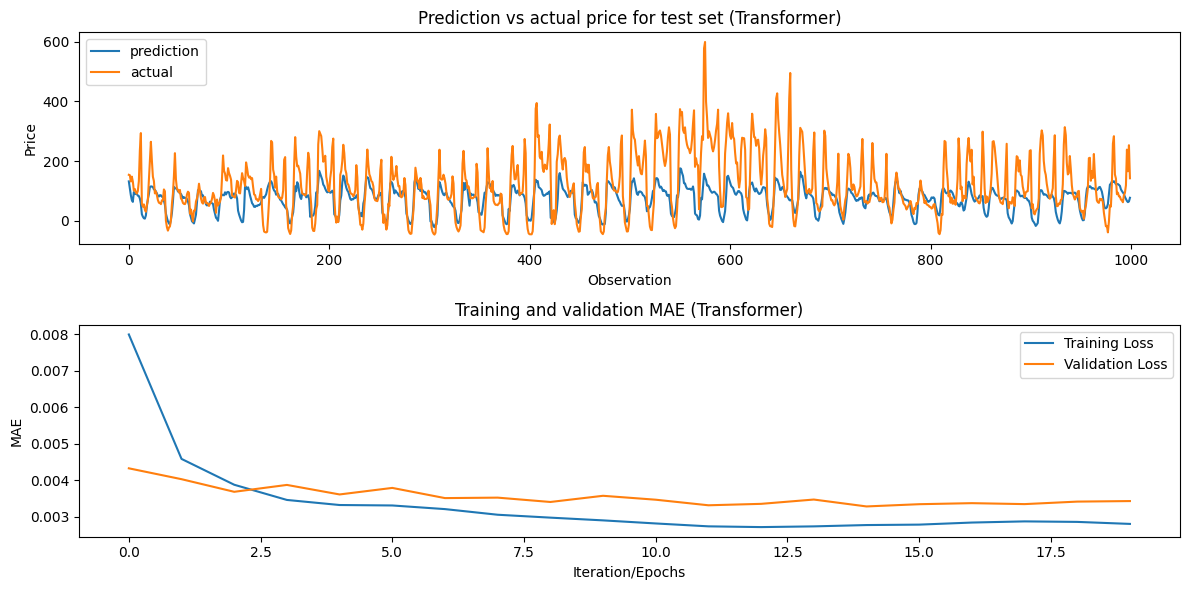


Scaled Performance:
Test MAE: 0.004991
Test RMSE: 0.023176

Actual Scale Performance:
Test MAE: 79.85
Test RMSE: 370.82


In [73]:
# 1. Get predictions
y_pred = model.predict(X_test)

# 2. Inverse transform to actual scale
y_pred_actual = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# 3. Call plot_results
plot_results(y_pred_actual, y_test_inv, model, model_name="Transformer")

# Optional: Also show scaled performance
print("\nScaled Performance:")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.6f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")

print("\nActual Scale Performance:")
print(f"Test MAE: {mean_absolute_error(y_test_inv, y_pred_actual):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_inv, y_pred_actual)):.2f}")

## Retrain Attention-LSTM + XGBoost 

LSTM-Attention is fitting a model on train-validation sets...

Epoch 1/100


The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:                                                 scale_fn=lambda x: 1/(2**(x-1)),



658/658 [==============================] - 13s 17ms/step - loss: 0.0064 - val_loss: 0.0053
Epoch 2/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0047 - val_loss: 0.0081
Epoch 3/100
658/658 [==============================] - 10s 16ms/step - loss: 0.0038 - val_loss: 0.0035
Epoch 4/100
658/658 [==============================] - 10s 16ms/step - loss: 0.0034 - val_loss: 0.0036
Epoch 5/100
658/658 [==============================] - 10s 16ms/step - loss: 0.0033 - val_loss: 0.0090
Epoch 6/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0032 - val_loss: 0.0059
Epoch 7/100
658/658 [==============================] - 10s 15ms/step - loss: 0.0030 - val_loss: 0.0042
Epoch 8/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0028 - val_loss: 0.0033
Epoch 9/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0026 - val_loss: 0.0033
Epoch 10/100
658/658 [==============================] - 11s 16ms/step - loss: 0.0024 

[17:07:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "verbose" } are not used.



164/164 [==============================] - 1s 3ms/step


---------------------------------------------------
LSTM-Attention-XGBoost MAE for test set : 0.00467
---------------------------------------------------



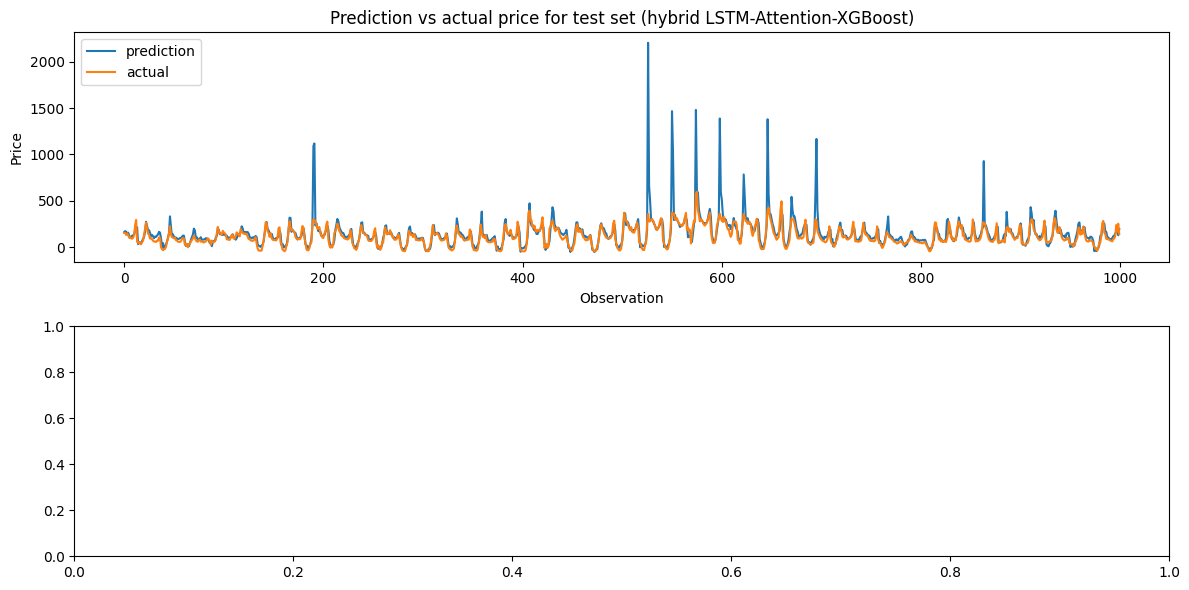

In [67]:
# inputs for DL models
epoch = 100
batch_size = 64
steps_per_epoch = len(X_train) // batch_size
cyclic_lr = tfa.optimizers.CyclicalLearningRate(initial_learning_rate=1e-04,
                                                maximal_learning_rate=1e-02,
                                                scale_fn=lambda x: 1/(2**(x-1)),
                                                step_size=6 * steps_per_epoch)

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
optimizer = Adam(learning_rate=cyclic_lr, amsgrad=True)

def LSTM_attention():
    inputs = Input(shape=(hist_size, X_train.shape[2]))
    #By masking the zeros, the model can learn to ignore the missing values and focus on the valid data.
    masked = Masking(mask_value=0.)(inputs)
    lstm = LSTM(132, return_sequences=True)(masked)
    attention = dot([lstm, lstm], axes=[2, 2])
    # extracting weight for every observation in the history size!
    attention = Dense(hist_size, activation='softmax')(attention)
    # assinging weight to lstm by dot product
    context = dot([attention, lstm], axes=[2, 1])
    flattened = Flatten()(context)
    output = Dense(1)(flattened)
    model = Model(inputs=inputs, outputs=output)
    
    return model
    
LSTM_attention_model = LSTM_attention()
LSTM_attention_model.compile(optimizer=optimizer, loss='mae')

def reshaping(X):
    
    reshaped_x = X.reshape(-1 , X.shape[1] * X.shape[2])
    return reshaped_x

X_train_xgb = reshaping(X_train)
X_val_xgb   = reshaping(X_val)
X_test_xgb  = reshaping(X_test)

print('LSTM-Attention is fitting a model on train-validation sets...')
print('')

LSTM_attention_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = epoch, 
                   batch_size = batch_size, callbacks=[callback])

print('')
print('----------------------------------')
print('LSTM-attention is predicting...')
print('')

residuals_train = y_train - LSTM_attention_model.predict(X_train)
residuals_val   = y_val - LSTM_attention_model.predict(X_val)

print('')
print('----------------------------------')
print('XGBoost is fitting a model on residuals...')
print('')


xgb_hybrid = xgb.XGBRegressor(     
               eval_metric='mae',
               early_stopping_rounds=8,
               verbose=False)
xgb_hybrid.fit(X_train_xgb, residuals_train,eval_set=[(X_train_xgb, residuals_train), (X_val_xgb, residuals_val)]) 


y_train_pred = LSTM_attention_model.predict(X_train) + xgb_hybrid.predict(X_train_xgb).reshape(-1,1)
y_val_pred   = LSTM_attention_model.predict(X_val)   + xgb_hybrid.predict(X_val_xgb).reshape(-1,1)

y_test_inv = scaler_y.inverse_transform(y_test)
y_test_pred  = LSTM_attention_model.predict(X_test) + xgb_hybrid.predict(X_test_xgb).reshape(-1,1)
print('')
print('')

print('---------------------------------------------------')
print(f'LSTM-Attention-XGBoost MAE for test set : {round(mean_absolute_error(y_test_pred,y_test),5)}')
print('---------------------------------------------------')
y_pred_actual = scaler_y.inverse_transform(y_test_pred)
print('')
plot_results(y_pred_actual, y_test_inv, 'hybrid' ,'hybrid LSTM-Attention-XGBoost')

In [74]:
y_train_pred = LSTM_attention_model.predict(X_train) + xgb_hybrid.predict(X_train_xgb).reshape(-1,1)
y_val_pred   = LSTM_attention_model.predict(X_val)   + xgb_hybrid.predict(X_val_xgb).reshape(-1,1)

y_test_inv = scaler_y.inverse_transform(y_test)
y_test_pred  = LSTM_attention_model.predict(X_test) + xgb_hybrid.predict(X_test_xgb).reshape(-1,1)

164/164 [==============================] - 1s 3ms/step


In [75]:
np.sqrt(mean_squared_error(y_test_pred, y_test))

0.020961747161301097

In [78]:
y_pred_actual = scaler_y.inverse_transform(y_test_pred)
print("\nScaled Performance:")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.6f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.6f}")

print("\nActual Scale Performance:")
print(f"Test MAE: {mean_absolute_error(y_test_inv, y_pred_actual):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_inv, y_pred_actual)):.2f}")


Scaled Performance:
Test MAE: 0.004672
Test RMSE: 0.020962

Actual Scale Performance:
Test MAE: 74.76
Test RMSE: 335.39


## retrain CNN + LSTM 

In [83]:
def base_model_cnn_lstm():
    
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=X_train.shape[-2:]))
    model.add(LSTM(units = 8, return_sequences = True, activation="relu"))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(1))
    
    return model

cnn_lstm_model = base_model_cnn_lstm()
cnn_lstm_model.compile(optimizer = optimizer , loss = 'mean_absolute_error')
cnn_lstm_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 22, 64)            1408      
                                                                 
 lstm_3 (LSTM)               (None, 22, 8)             2336      
                                                                 
 flatten_3 (Flatten)         (None, 176)               0         
                                                                 
 dense_42 (Dense)            (None, 256)               45312     
                                                                 
 dense_43 (Dense)            (None, 1)                 257       
                                                                 
Total params: 49313 (192.63 KB)
Trainable params: 49313 (192.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [84]:
history = cnn_lstm_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = epoch, 
                   batch_size = batch_size, callbacks=[callback])

Epoch 1/100
658/658 [==============================] - 3s 3ms/step - loss: 0.0055 - val_loss: 0.0036
Epoch 2/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 3/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 4/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0029 - val_loss: 0.0036
Epoch 5/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0028 - val_loss: 0.0031
Epoch 6/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0027 - val_loss: 0.0036
Epoch 7/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 8/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0025 - val_loss: 0.0031
Epoch 9/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0024 - val_loss: 0.0030
Epoch 10/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0024 - val_lo

164/164 [==============================] - 0s 645us/step


---------------------------------------------------
CNN-LSTM MAE for test set : 0.00424
---------------------------------------------------



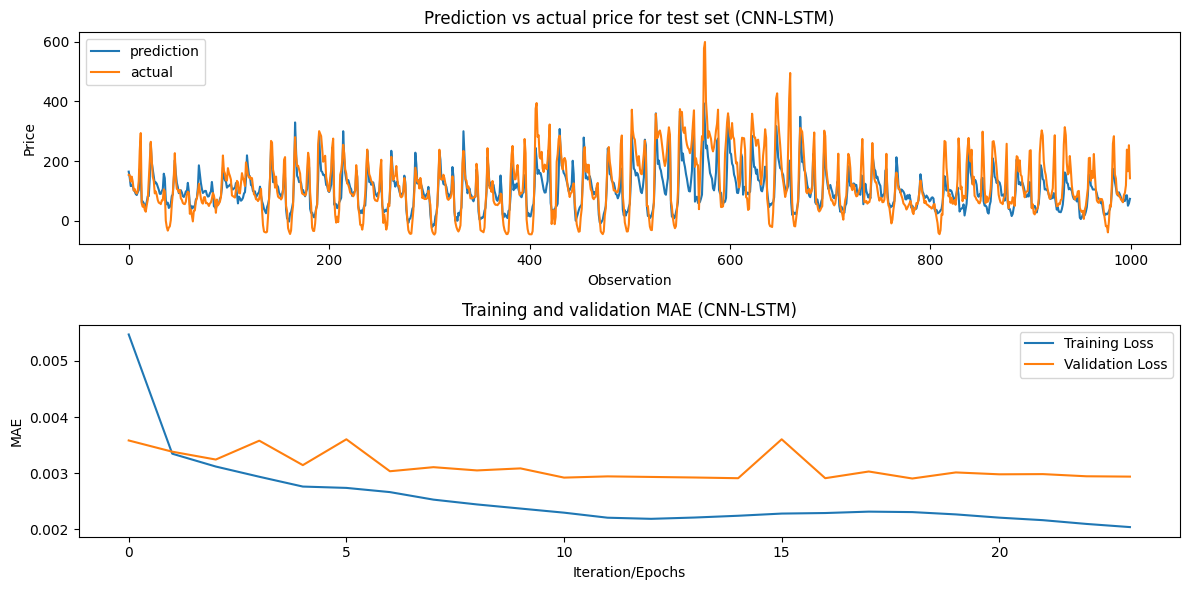

In [85]:
y_pred = cnn_lstm_model.predict(X_test)
print('')
print('')
print('---------------------------------------------------')
print(f'CNN-LSTM MAE for test set : {round(mean_absolute_error(y_pred,y_test),5)}')
print('---------------------------------------------------')
y_pred_actual = scaler_y.inverse_transform(y_pred)
print('')
plot_results(y_pred_actual, y_test_inv, history,'CNN-LSTM')

In [86]:
np.sqrt(mean_squared_error(y_pred, y_test))

0.02159348560017551

In [87]:
print("\nScaled Performance:")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.6f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")

print("\nActual Scale Performance:")
print(f"Test MAE: {mean_absolute_error(y_test_inv, y_pred_actual):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_inv, y_pred_actual)):.2f}")


Scaled Performance:
Test MAE: 0.004237
Test RMSE: 0.021593

Actual Scale Performance:
Test MAE: 67.79
Test RMSE: 345.50


## GRU

In [96]:
def base_model_gru():
    
    model = Sequential()
    model.add(GRU(units=32, return_sequences=True, activation="relu", input_shape=X_train.shape[-2:]))
    model.add(Flatten())
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    
    return model

gru_model = base_model_gru()

In [97]:
# inputs for DL models
epoch = 100
batch_size = 64
steps_per_epoch = len(X_train) // batch_size
cyclic_lr = tfa.optimizers.CyclicalLearningRate(initial_learning_rate=1e-04,
                                                maximal_learning_rate=1e-02,
                                                scale_fn=lambda x: 1/(2**(x-1)),
                                                step_size=6 * steps_per_epoch)

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8)
optimizer = Adam(learning_rate=cyclic_lr, amsgrad=True)

In [98]:
gru_model.compile(optimizer = optimizer , loss = 'mean_absolute_error')
history = gru_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = epoch, 
                   batch_size = batch_size, callbacks=[callback])

Epoch 1/100
658/658 [==============================] - 3s 4ms/step - loss: 0.0093 - val_loss: 0.0034
Epoch 2/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0029 - val_loss: 0.0034
Epoch 3/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0028 - val_loss: 0.0042
Epoch 4/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0029 - val_loss: 0.0035
Epoch 5/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0029 - val_loss: 0.0039
Epoch 6/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0029 - val_loss: 0.0047
Epoch 7/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0028 - val_loss: 0.0037
Epoch 8/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 9/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0026 - val_loss: 0.0039


164/164 [==============================] - 0s 716us/step


---------------------------------------------------
GRU MAE for test set : 0.004
---------------------------------------------------



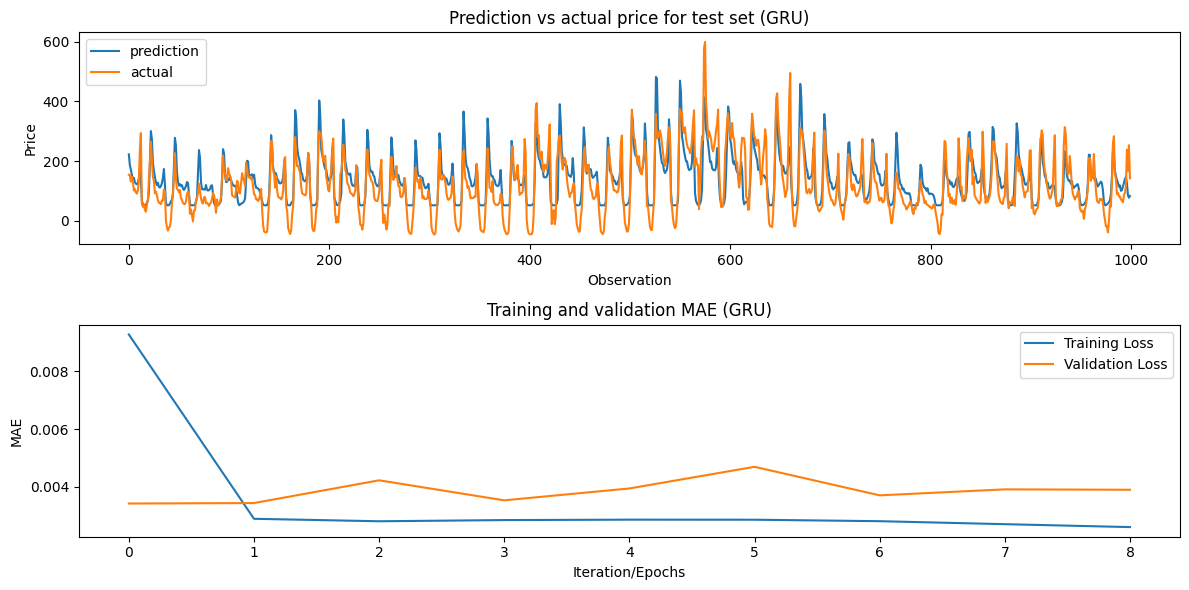

In [99]:
y_pred = gru_model.predict(X_test)
y_pred_actual = scaler_y.inverse_transform(y_pred.reshape(-1,1))
y_test_inv = scaler_y.inverse_transform(y_test)
print('')
print('')
print('---------------------------------------------------')
print(f'GRU MAE for test set : {round(mean_absolute_error(y_pred,y_test),3)}')
print('---------------------------------------------------')
y_pred_actual = scaler_y.inverse_transform(y_pred)
print('')
plot_results(y_pred_actual, y_test_inv, history,'GRU')

In [100]:
np.sqrt(mean_squared_error(y_pred, y_test))

0.021166791406207457

In [101]:
print("\nScaled Performance:")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.6f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")

print("\nActual Scale Performance:")
print(f"Test MAE: {mean_absolute_error(y_test_inv, y_pred_actual):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_inv, y_pred_actual)):.2f}")


Scaled Performance:
Test MAE: 0.004222
Test RMSE: 0.021167

Actual Scale Performance:
Test MAE: 67.55
Test RMSE: 338.67


## LSTM

In [102]:
def base_model_lstm():

    model = Sequential()
    model.add(LSTM(units = 32, return_sequences = True, activation="relu", input_shape = X_train.shape[-2:]))
    model.add(Flatten())
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    
    return model

lstm_model = base_model_lstm()
lstm_model.compile(optimizer = optimizer , loss = 'mean_absolute_error')
lstm_model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_5 (LSTM)               (None, 24, 32)            5120      
                                                                 
 flatten_7 (Flatten)         (None, 768)               0         
                                                                 
 dense_50 (Dense)            (None, 128)               98432     
                                                                 
 dropout_35 (Dropout)        (None, 128)               0         
                                                                 
 dense_51 (Dense)            (None, 1)                 129       
                                                                 
Total params: 103681 (405.00 KB)
Trainable params: 103681 (405.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:                                                 scale_fn=lambda x: 1/(2**(x-1)),



In [103]:
history = lstm_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs =epoch, 
                   batch_size = batch_size, callbacks=[callback])

Epoch 1/100
658/658 [==============================] - 3s 4ms/step - loss: 0.0092 - val_loss: 0.0038
Epoch 2/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0029 - val_loss: 0.0035
Epoch 3/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0028 - val_loss: 0.0038
Epoch 4/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0028 - val_loss: 0.0034
Epoch 5/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0028 - val_loss: 0.0033
Epoch 6/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0028 - val_loss: 0.0032
Epoch 7/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0028 - val_loss: 0.0032
Epoch 8/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 9/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0025 - val_loss: 0.0031
Epoch 10/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0024 - val_lo

164/164 [==============================] - 0s 959us/step


---------------------------------------------------
LSTM MAE for test set : 0.004
---------------------------------------------------



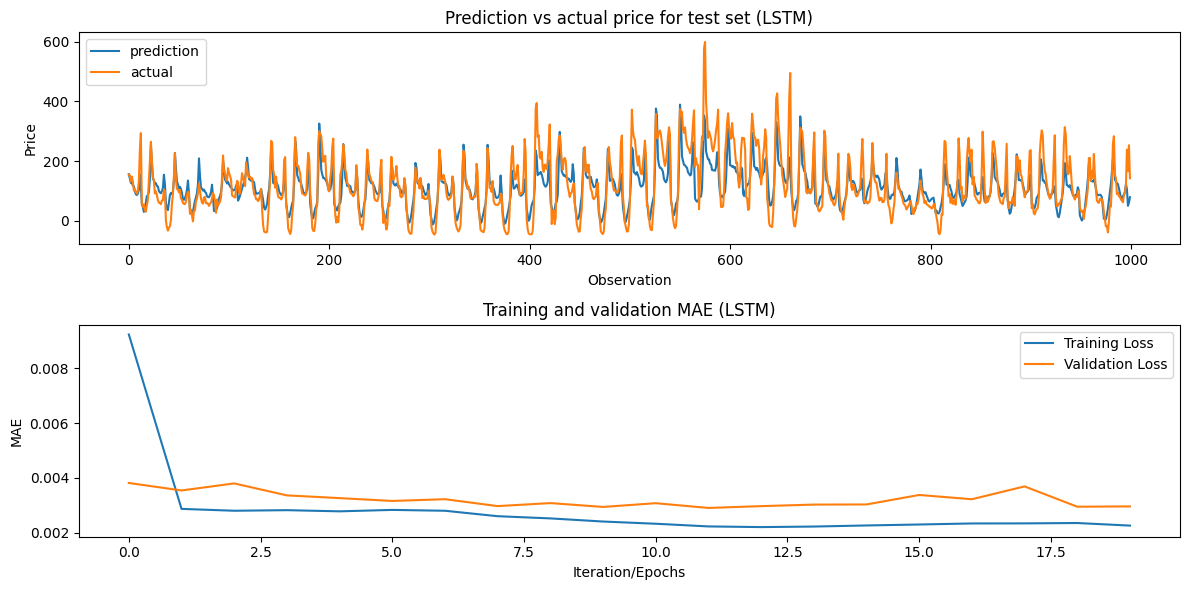

In [104]:
y_pred = lstm_model.predict(X_test)
print('')
print('')
print('---------------------------------------------------')
print(f'LSTM MAE for test set : {round(mean_absolute_error(y_pred,y_test),3)}')
print('---------------------------------------------------')
y_pred_actual = scaler_y.inverse_transform(y_pred)
print('')
plot_results(y_pred_actual, y_test_inv, history,'LSTM')

In [105]:
np.sqrt(mean_squared_error(y_pred, y_test))

0.02202227544752045

In [106]:
print("\nScaled Performance:")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.6f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")

print("\nActual Scale Performance:")
print(f"Test MAE: {mean_absolute_error(y_test_inv, y_pred_actual):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_inv, y_pred_actual)):.2f}")


Scaled Performance:
Test MAE: 0.003696
Test RMSE: 0.022022

Actual Scale Performance:
Test MAE: 59.13
Test RMSE: 352.36


# save all models

In [107]:
model.save("models/mutivariate_enhanced_transformer_model.h5")
LSTM_attention_model.save("models/mutivariate_LSTM_attention_model.h5")
cnn_lstm_model.save("models/mutivariate_cnn_LSTM_model.h5")
gru_model.save("models/mutivariate_GRU_model.h5")
lstm_model.save("models/mutivariate_LSTM_model.h5")

You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:                                                     scale_fn=lambda x: 1/(2**(x-1)),

The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:                                                 scale_fn=lambda x: 1/(2**(x-1)),



# Test to see whether renewable energy has an impact or not

                                     RRP
RRP                             1.000000
Coal_Seam_Methane_Generation    0.321578
Kerosene_Generation             0.292716
Water_Generation                0.287632
Natural_Gas_Generation          0.218369
Black_Coal_Generation           0.117626
Grid_Generation                 0.090476
Hour                            0.087271
Year                            0.079634
Wind_Generation                 0.006670
Bagasse_and_Diesel_Generation   0.005953
Month                          -0.019576
Waste_Coal_Mine_Gas_Generation -0.044780
Bagasse_Generation             -0.046480
WeekDay                        -0.046566
Solar_Generation               -0.124022
Solar__Generation              -0.144559


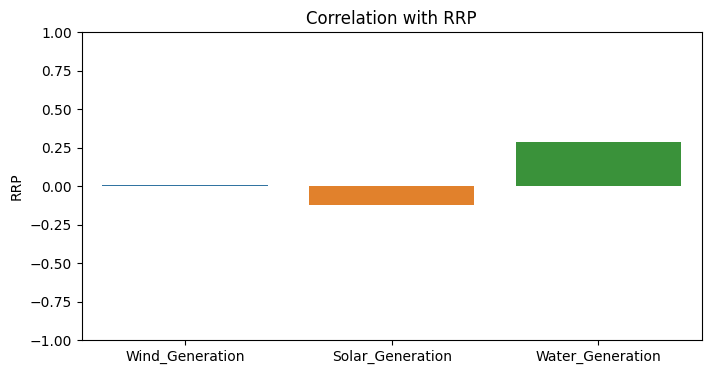

In [10]:
# Calculate correlations with RRP
corr_with_rrp = df_scada_price_qld.corr()[['RRP']].sort_values('RRP', ascending=False)
print(corr_with_rrp)

# Plot correlations for Wind, Solar, Water
features_to_check = ['Wind_Generation', 'Solar_Generation', 'Water_Generation']
plt.figure(figsize=(8, 4))
sns.barplot(x=corr_with_rrp.loc[features_to_check].index, y=corr_with_rrp.loc[features_to_check]['RRP'])
plt.title("Correlation with RRP")
plt.ylim(-1, 1)
plt.show()

In [14]:
from sklearn.ensemble import RandomForestRegressor

# Fit a simple Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(df_scada_price_qld.drop(columns=['RRP']), df_scada_price_qld['RRP'])

# Get feature importance
importance = pd.DataFrame({
    'Feature': df_scada_price_qld.drop(columns=['RRP']).columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

                           Feature  Importance
3     Coal_Seam_Methane_Generation    0.206133
10                Water_Generation    0.188315
2            Black_Coal_Generation    0.120429
6           Natural_Gas_Generation    0.083978
5              Kerosene_Generation    0.071386
7                 Solar_Generation    0.055636
11                 Wind_Generation    0.048503
8                Solar__Generation    0.043066
15                            Year    0.036973
9   Waste_Coal_Mine_Gas_Generation    0.035435
12                            Hour    0.028635
4                  Grid_Generation    0.027163
13                           Month    0.021712
14                         WeekDay    0.021135
0               Bagasse_Generation    0.007413
1    Bagasse_and_Diesel_Generation    0.004086
